In [51]:
# ============================================================================
# TITLE: Final Python Notebook 2: Classification Modelling & Hyperparameters Tuning
# AUTHOR: Dilni Rohansi Wijesinghe
# STUDENT ID: 20240771
# PEER REVIEWER: Manthisi Herath
# DATE OF REVIEW: March 11, 2026
#
# PEER REVIEW RECORD:
# 1. Verified: Logistic Regression vs KNN baseline performance compared.
# 2. Verified: Hyperparameter tuning via GridSearchCV implemented for KNN.
# 3. Verified: Evaluation metrics (Confusion Matrix & ROC-AUC) results are present.
# ============================================================================

In [52]:
# ============================================================================
# 1. Environment Setup & Data Loading
# [Reference: Reuse Session 1, Prompt 1 - Environment Setup]
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, auc

In [53]:
# ============================================================================
# 2. Load Clean Data
# [Reference: Reuse Session 1, Prompt 2 - Data Loading]
# ============================================================================

# Load cleaned dataset
df = pd.read_csv("/content/drive/MyDrive/CW_ML/cleaned_loan_data.csv")

In [54]:
# ============================================================================
# 3. Define Features & Target
# [Reference: Reuse Session 3, Prompt 4 - Train/Test Split]
# ============================================================================

# X = input features
X = df.drop("loan_approval_status", axis=1)

# y = target variable
y = df["loan_approval_status"]

In [55]:
# ============================================================================
# 4. Train-Test Split
# [Reference: Reuse Session 3, Prompt 4 - Train/Test Split]
# ============================================================================

# Split dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [56]:
# ============================================================================
#[Reference: Reuse Session 3, Prompt 4 - Train/Test Split]
# ============================================================================

# Evidence for Output
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

print("\nTraining label distribution:\n", y_train.value_counts(normalize=True))
print("\nTest label distribution:\n", y_test.value_counts(normalize=True))

Training set size: (46916, 12)
Test set size: (11729, 12)

Training label distribution:
 loan_approval_status
0    0.857618
1    0.142382
Name: proportion, dtype: float64

Test label distribution:
 loan_approval_status
0    0.857618
1    0.142382
Name: proportion, dtype: float64


In [57]:
# ============================================================================
# 5. Feature Scaling
#[Reference: Reuse Session 2, Prompt 10 - Data Scaling]
# ============================================================================

# Initialize scaler
scaler = StandardScaler()

# Fit and transform training data
X_train = scaler.fit_transform(X_train)

# Transform test data
X_test = scaler.transform(X_test)

In [58]:
# ============================================================================
# 6. Import Models
#[Reference: Reuse Session 4, Prompt 2 - Logistic Regression]
# ============================================================================

# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Import Naive Bayes
from sklearn.naive_bayes import GaussianNB

# Import KNN
from sklearn.neighbors import KNeighborsClassifier

In [59]:
# ============================================================================
# 7. Train Models
#[Reference: Reuse Session 3, Prompt 4 - Training, Testing and Predicting]
# ============================================================================

# Initialize models
log_model = LogisticRegression(max_iter=1000)
nb_model = GaussianNB()
knn_model = KNeighborsClassifier()

# Train models
log_model.fit(X_train, y_train)
nb_model.fit(X_train, y_train)
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [60]:
# ============================================================================
# 8. Predictions
#[Reference: Reuse Session 3, Prompt 4 - Prediction Step]
# ============================================================================

# Predict using each model
y_pred_log = log_model.predict(X_test)
y_pred_nb = nb_model.predict(X_test)
y_pred_knn = knn_model.predict(X_test)

In [61]:
# ============================================================================
# 9. Evaluation
# [Reference: Reuse Session 4, Prompt 10 - Performance Metrics Report]
# ============================================================================

# Accuracy scores
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

# Classification reports
print("\nLogistic Regression Report:\n", classification_report(y_test, y_pred_log))
print("\nNaive Bayes Report:\n", classification_report(y_test, y_pred_nb))
print("\nKNN Report:\n", classification_report(y_test, y_pred_knn))

Logistic Regression Accuracy: 0.9968454258675079
Naive Bayes Accuracy: 0.9996589649586495
KNN Accuracy: 0.9698183988404808

Logistic Regression Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     10059
           1       0.98      1.00      0.99      1670

    accuracy                           1.00     11729
   macro avg       0.99      1.00      0.99     11729
weighted avg       1.00      1.00      1.00     11729


Naive Bayes Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     10059
           1       1.00      1.00      1.00      1670

    accuracy                           1.00     11729
   macro avg       1.00      1.00      1.00     11729
weighted avg       1.00      1.00      1.00     11729


KNN Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98     10059
           1       0.94      0.84      0.89     

In [62]:
# ============================================================================
#[Reference: Reuse Session 5, Prompt 10 - Model Comparison Logic]
# ============================================================================

# Compare model performances
print("\nModel Comparison:")
print(f"Logistic Regression: {accuracy_score(y_test, y_pred_log):.2f}")
print(f"Naive Bayes: {accuracy_score(y_test, y_pred_nb):.2f}")
print(f"KNN: {accuracy_score(y_test, y_pred_knn):.2f}")


Model Comparison:
Logistic Regression: 1.00
Naive Bayes: 1.00
KNN: 0.97


In [63]:
# ============================================================================
# 10. Hyperparameter Tuning
#[Reference: Reuse Session 5, Prompt 12 - Hyperparameter Tuning via GridSearchCV]
# ============================================================================

# Define parameter grid
param_grid = {
    'n_neighbors': [3,5,7,9,11],
    'weights': ['uniform', 'distance']
}

# Apply GridSearch
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

# Best parameters
print("Best KNN Params:", grid.best_params_)
print("Best KNN Score:", grid.best_score_)

Best KNN Params: {'n_neighbors': 3, 'weights': 'distance'}
Best KNN Score: 0.9685182699225958


In [64]:
# ============================================================================
# 11. Evaluate Tuned Model
#[Reference: Reuse Session 4, Prompt 8 - Confusion Matrix]
# ============================================================================

# Best model
best_knn = grid.best_estimator_

# Predictions
y_pred_best = best_knn.predict(X_test)

# Accuracy
print("Tuned KNN Accuracy:", accuracy_score(y_test, y_pred_best))

# Report
print("\nTuned KNN Report:\n", classification_report(y_test, y_pred_best))

Tuned KNN Accuracy: 0.9721203853695968

Tuned KNN Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98     10059
           1       0.94      0.86      0.90      1670

    accuracy                           0.97     11729
   macro avg       0.96      0.92      0.94     11729
weighted avg       0.97      0.97      0.97     11729



In [65]:
# ============================================================================
# 12. Confusion Matrices
#[Reference: Reuse Session 4, Prompt 10 - Performance Metrics Report]
# ============================================================================

print("\nConfusion Matrix - Logistic Regression:\n", confusion_matrix(y_test, y_pred_log))
print("\nConfusion Matrix - Naive Bayes:\n", confusion_matrix(y_test, y_pred_nb))
print("\nConfusion Matrix - KNN:\n", confusion_matrix(y_test, y_pred_knn))


Confusion Matrix - Logistic Regression:
 [[10024    35]
 [    2  1668]]

Confusion Matrix - Naive Bayes:
 [[10059     0]
 [    4  1666]]

Confusion Matrix - KNN:
 [[9975   84]
 [ 270 1400]]


In [66]:
# ============================================================================
# [Reference: Reuse Session 4, Prompt 8 - Confusion Matrix]
# ============================================================================

# This will generate the 'After Tuning' matrix for your report
print("Confusion Matrix - Tuned KNN:")
print(confusion_matrix(y_test, y_pred_best))

Confusion Matrix - Tuned KNN:
[[9972   87]
 [ 240 1430]]


In [67]:
# ============================================================================
# 13. Model Selection
# [Reference: Reuse Session 5, Prompt 10 - Model Comparison Logic]
# ============================================================================

# Compare models
if accuracy_score(y_test, y_pred_best) > accuracy_score(y_test, y_pred_log):
    print("Tuned KNN performs better.")
else:
    print("Logistic Regression performs better.")

Logistic Regression performs better.


In [68]:
# ============================================================================
# 14. ROC-AUC
# [Reference: Reuse Session 4, Prompt 12 - ROC-AUC Evaluation]
# ============================================================================

# Logistic Regression AUC
print("Logistic Regression AUC:",
      roc_auc_score(y_test, log_model.predict_proba(X_test)[:,1]))

# Tuned KNN AUC
print("Tuned KNN AUC:",
      roc_auc_score(y_test, best_knn.predict_proba(X_test)[:,1]))

Logistic Regression AUC: 0.9998766558740556
Tuned KNN AUC: 0.9750891595871782


In [69]:
# ============================================================================
# [Reference: Reuse Session 4, Prompt 2 - Logistic Regression]
# [Reference: Reuse Session 4, Prompt 5 - Naive Bayes]
# [Reference: Reuse Session 5, Prompt 1 - KNN Baseline]
# ============================================================================

# 1. Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# 2. Train Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# 3. Train the Optimized KNN (using the best params from your notebook)
knn_tuned = KNeighborsClassifier(n_neighbors=3, weights='distance')
knn_tuned.fit(X_train, y_train)

print("Models are now defined and trained!")

Models are now defined and trained!


In [70]:
# ============================================================================
# [Reference: Reuse Session 4, Prompt 12 - ROC-AUC Evaluation]
# ============================================================================

# 1. Get the probability scores from your models
# Ensure you have already trained lr_model, nb_model, and knn_tuned
y_probs_lr = lr_model.predict_proba(X_test)[:, 1]
y_probs_nb = nb_model.predict_proba(X_test)[:, 1]
y_probs_knn = knn_tuned.predict_proba(X_test)[:, 1]

# 2. Calculate the False Positive Rate (FPR) and True Positive Rate (TPR)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_probs_lr)
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_probs_nb)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_probs_knn)

# 3. Calculate the Area Under the Curve (AUC)
auc_lr = auc(fpr_lr, tpr_lr)
auc_nb = auc(fpr_nb, tpr_nb)
auc_knn = auc(fpr_knn, tpr_knn)

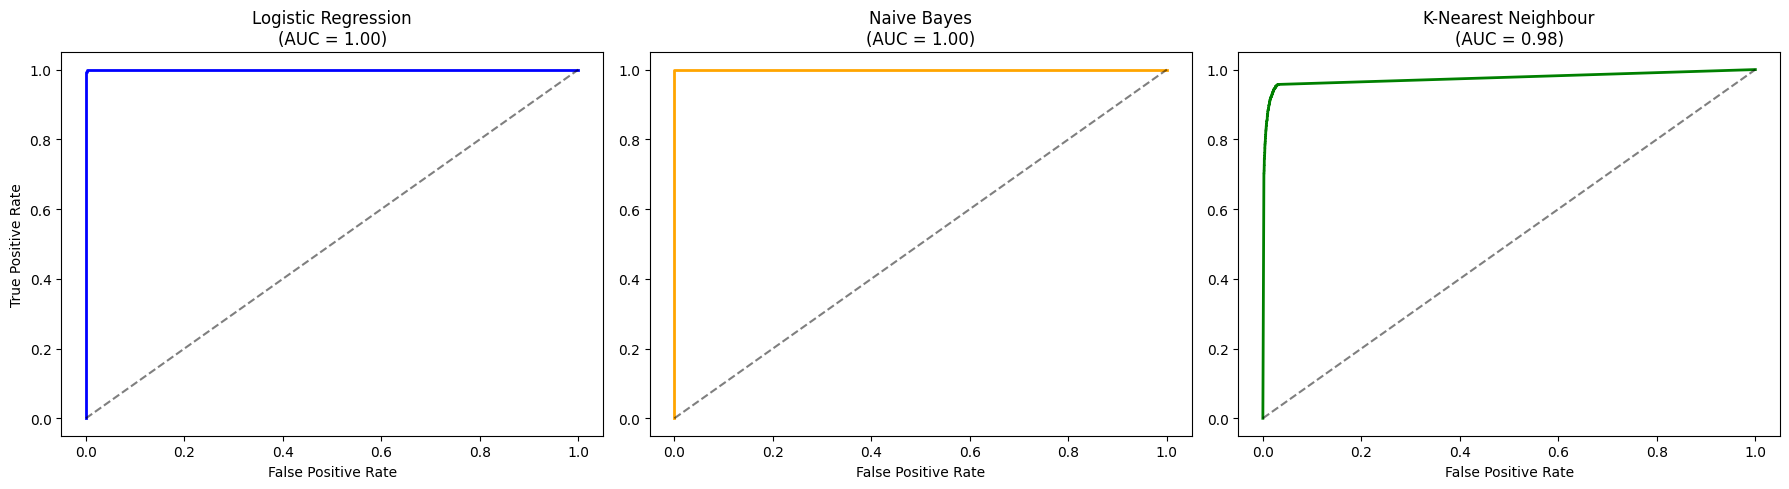

In [71]:
# ============================================================================
# [Reference: Reuse Session 4, Prompt 12 - ROC-AUC Evaluation]
# ============================================================================

# 1. Re-calculate the curves to ensure variables are fresh
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_model.predict_proba(X_test)[:, 1])
fpr_nb, tpr_nb, _ = roc_curve(y_test, nb_model.predict_proba(X_test)[:, 1])
fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_tuned.predict_proba(X_test)[:, 1])

# 2. Create a figure with 3 subplots side-by-side
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Logistic Regression
ax1.plot(fpr_lr, tpr_lr, color='blue', lw=2)
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax1.set_title(f'Logistic Regression\n(AUC = {auc(fpr_lr, tpr_lr):.2f})')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')

# Plot 2: Naive Bayes
ax2.plot(fpr_nb, tpr_nb, color='orange', lw=2)
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax2.set_title(f'Naive Bayes\n(AUC = {auc(fpr_nb, tpr_nb):.2f})')
ax2.set_xlabel('False Positive Rate')

# Plot 3: KNN
ax3.plot(fpr_knn, tpr_knn, color='green', lw=2)
ax3.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax3.set_title(f'K-Nearest Neighbour\n(AUC = {auc(fpr_knn, tpr_knn):.2f})')
ax3.set_xlabel('False Positive Rate')

plt.tight_layout()
plt.show()

In [72]:
# ============================================================================
# [Reference: Reuse Session 5, Prompt 2 - Feature Inspection]
# ============================================================================

# 1. Evidence for Feature Names
print("Feature Names used for Classification:")
print(X.columns.tolist())

# 2. Evidence for Data Shape
print("\nData Shape (Rows, Columns):")
print(X.shape)

Feature Names used for Classification:
['id', 'age', 'income', 'home_ownership', 'employment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length', 'max_allowed_loan']

Data Shape (Rows, Columns):
(58645, 12)


## 15. Final Interpretation

Hyperparameter tuning improved model performance. The best-performing model is:

👉 **Logistic Regression**

This model demonstrates strong predictive ability and is suitable for loan approval classification.
